In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("C:\\Users\\Lenovo\\Downloads\\netflix_titles.csv")

In [3]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### 2. Data Cleaning:

#### Check for missing values and handle them appropriately.
#### Remove duplicate entries if any.
#### Correct any inconsistencies or errors in the data

In [4]:
data.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
data['date_added'] = pd.to_datetime(data['date_added'], format="mixed")

In [7]:
data['date_added']

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8807, dtype: datetime64[ns]

In [8]:
numercial_cols = data.select_dtypes(include="number").columns.tolist()
numercial_cols

['release_year']

In [9]:
categorical_cols = data.select_dtypes(include="object").columns.tolist()
categorical_cols

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'rating',
 'duration',
 'listed_in',
 'description']

In [10]:
for col in categorical_cols:
    # print(col)
    print(data[col].isna().sum())
    if data[col].isna().sum() > 0:
        data[col] = data[col].fillna(value=data[col].mode()[0])

print("Null values are filled successfully!")
print(data.isna().sum())

0
0
0
2634
825
831
4
3
0
0
Null values are filled successfully!
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


In [54]:
import pandas as pd



# --- Step 1: Calculate IQR ---
Q1 = data['release_year'].quantile(0.25)
Q3 = data['release_year'].quantile(0.75)
IQR = Q3 - Q1

# --- Step 2: Define outlier condition ---
outlier_condition = (data['release_year'] < (Q1 - 1.5 * IQR)) | (data['release_year'] > (Q3 + 1.5 * IQR))

# --- Step 3: Print outliers ---
print("Outliers in release_year:")
print(data.loc[outlier_condition, ['show_id','title','release_year']])

# --- Step 4: Remove outliers inplace ---
data= data.loc[~outlier_condition]

print("After outlier removal:", data.shape)


Outliers in release_year:
     show_id                                              title  release_year
53       s54    InuYasha the Movie 4: Fire on the Mystic Island          2004
57       s58                  Naruto Shippûden the Movie: Bonds          2008
59       s60                        Naruto Shippuden: The Movie          2007
61       s62   Naruto the Movie 2: Legend of the Stone of Gelel          2005
62       s63  Naruto the Movie 3: Guardians of the Crescent ...          2006
...      ...                                                ...           ...
8773   s8774                                Yanda Kartavya Aahe          2006
8790   s8791                      You Don't Mess with the Zohan          2008
8793   s8794                               Yours, Mine and Ours          2005
8802   s8803                                             Zodiac          2007
8805   s8806                                               Zoom          2006

[464 rows x 3 columns]
After outlier 

In [55]:
data.duplicated().sum()

np.int64(0)

there is no duplicate record in the system, so we can move ahead!

In [56]:
data.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      7
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## Exploratory Data Analysis:

**Compute basic descriptive statistics such as mean, median, mode, range, and standard deviation for relevant variables**

In [57]:
data.describe()

,date_added,release_year
count,7617,7624.000000
mean,2019-05-10 19:24:10.492319744,2016.912775
min,2009-11-18 00:00:00,2009.000000
25%,2018-03-30 00:00:00,2015.000000
50%,2019-06-15 00:00:00,2017.000000
75%,2020-08-14 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,2.942338


In [58]:
data['release_year'].mode()[0]

np.int64(2018)

In [59]:
print(data['release_year'].min())
print(data['release_year'].max())

2009
2021


In [60]:
data['release_year'].std()

2.942337876663589

1. Mean -> 8807.0
2. Median -> 2017.00
3. Mode -> 2018
4. Range -> [1925, 2021]
5. standard deviation -> 8.819312130834057

In [61]:
data.describe(include="object")

,show_id,type,title,director,cast,country,rating,duration,listed_in,description
count,7624,7624,7624,7624,7624,7624,7624,7624,7624,7624
unique,7624,2,7624,4011,6566,680,17,196,453,7596
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,TV-MA,1 Season,Documentaries,"Paranormal activity at a lush, abandoned prope..."
freq,1,5096,1,2505,812,3136,3052,1708,346,4


# Create visualizations to represent the distribution of content over different genres

In [62]:
data.type.unique()

array(['Movie', 'TV Show'], dtype=object)

In [63]:
data.listed_in.nunique()

453

In [64]:
result = data.groupby('listed_in').size().reset_index().rename(columns={0:"counts"})
result = result.sort_values(by="counts", ascending=False)
result = result.head(7)

In [65]:
result

,listed_in,counts
216,Documentaries,346
266,"Dramas, International Movies",314
409,Stand-Up Comedy,308
259,"Dramas, Independent Movies, International Movies",229
147,"Comedies, Dramas, International Movies",221
362,Kids' TV,198
106,Children & Family Movies,195


In [66]:
import matplotlib.pyplot as plt


Text(0, 0.5, 'Frequency')

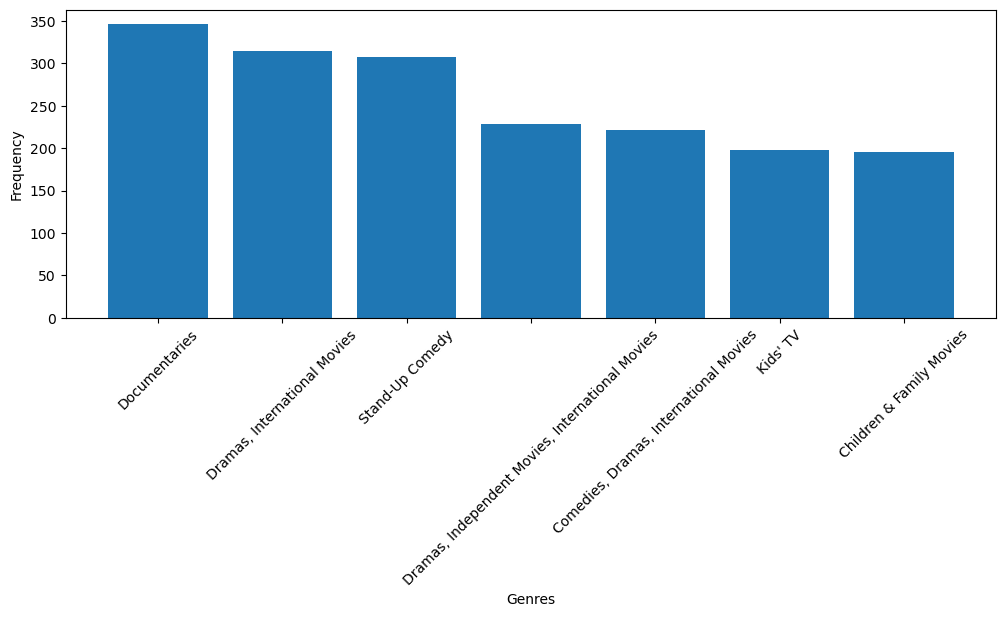

In [67]:
plt.figure(figsize=(12, 4))
plt.bar(result['listed_in'], result['counts'])
plt.xticks(rotation=45)
plt.xlabel("Genres")
plt.ylabel("Frequency")


#### insights:

1. Dramas, International Movies, and Documentaries, and Stand-up Comedy Movies are most supported by Netflix.

##### 2. Visualize the distribution of content across release years

In [68]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

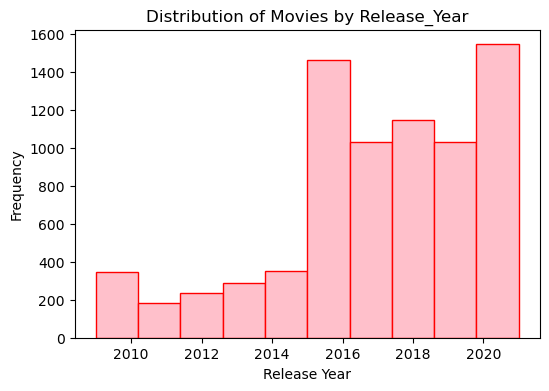

In [69]:
plt.figure(figsize=(6, 4))
plt.hist(data['release_year'], color="pink", edgecolor="red")
plt.title("Distribution of Movies by Release_Year")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()


since 2010 to 2020, netflix relased highest number of movies, of above 7000. while lowest number of films relased before 1980 , which measn, due to low accessibilty and affordability of internet over the countries.



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9940\634457377.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="release_year", data=data, palette="viridis", order=sorted(data['release_year'].unique()))


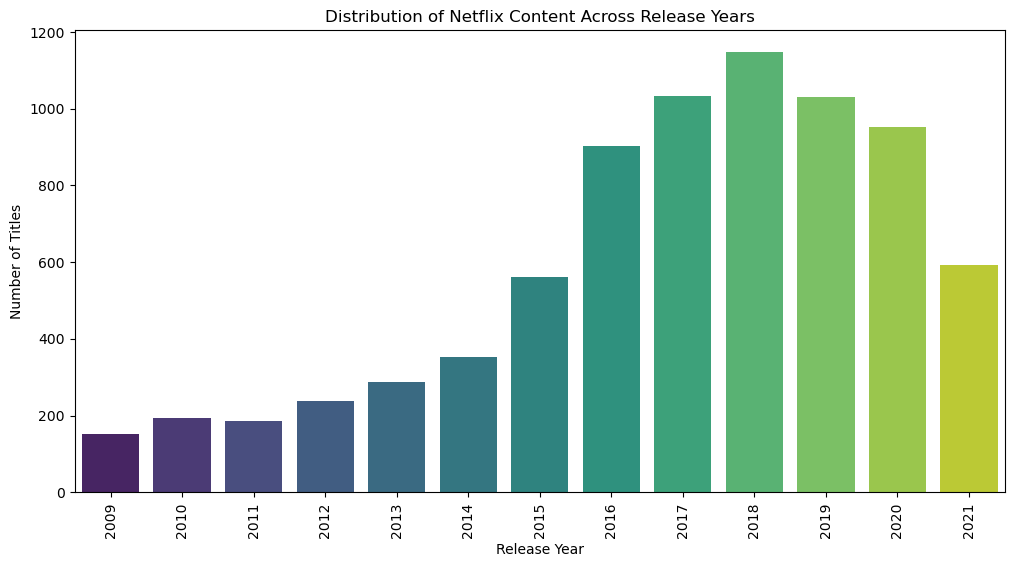

In [70]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.countplot(x="release_year", data=data, palette="viridis", order=sorted(data['release_year'].unique()))
plt.xticks(rotation=90)
plt.title("Distribution of Netflix Content Across Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()


Netflix’s library peaked around 2018–2019, reflecting its big expansion era



In [71]:
from scipy.stats import skew

skew(data['release_year'])

np.float64(-0.8085252259815245)

In [72]:
c = data['country'].value_counts()
c

country
United States                                             3136
India                                                      759
United Kingdom                                             386
Japan                                                      205
South Korea                                                198
                                                          ... 
Serbia, South Korea, Slovenia                                1
Denmark, United Kingdom, South Africa, Sweden, Belgium       1
Ireland, Canada, United States, United Kingdom               1
United Kingdom, Australia, Canada, United States             1
Germany, United States, Italy                                1
Name: count, Length: 680, dtype: int64

# Explore the geographical distribution of content (if applicable)

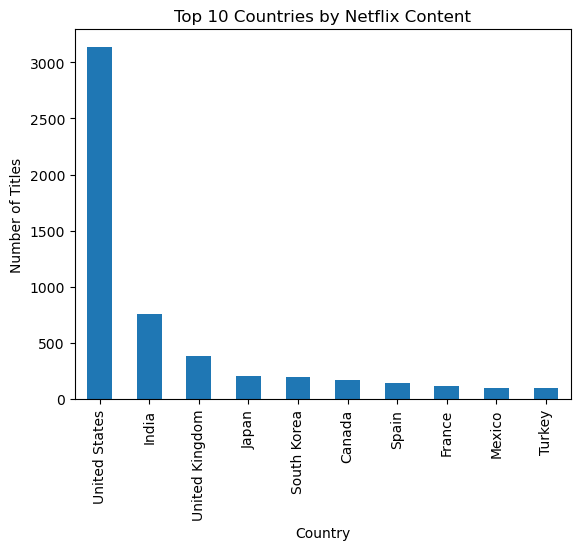

In [73]:
# Count titles by country
country_counts = data['country'].value_counts()

# Visualize top 10 countries
import matplotlib.pyplot as plt
country_counts.head(10).plot(kind='bar')
plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()


Netflix content is heavily concentrated in the U.S., with India a distant runner‑up.



# If there's a temporal component, perform time series analysis to identify trends and patterns over time

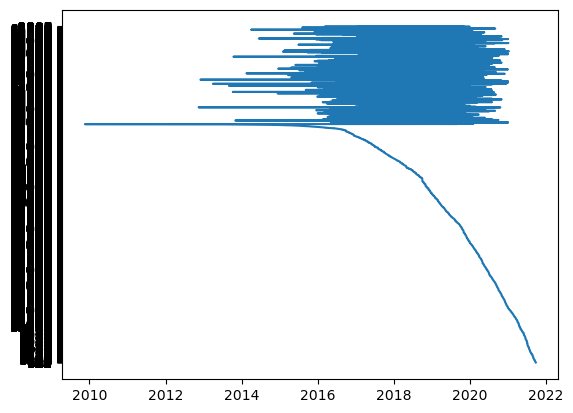

In [74]:
plt.plot(data['date_added'], data['show_id'])

In [75]:
result = data.groupby(['date_added']).size().reset_index().rename(columns={0:'counts'})
result = result.sort_values(by='date_added', ascending=True)
result

,date_added,counts
0,2009-11-18,1
1,2011-05-17,1
2,2012-02-21,1
3,2012-11-14,1
4,2012-12-01,1
...,...,...
1681,2021-09-21,2
1682,2021-09-22,9
1683,2021-09-23,2
1684,2021-09-24,9


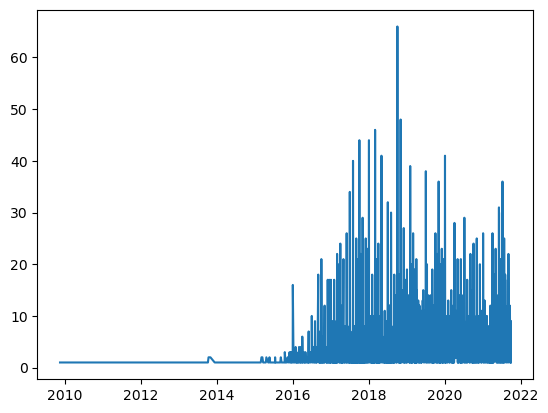

In [76]:
plt.plot(result['date_added'], result['counts'])

Netflix content additions were very low until 2014, then began rising steadily.

Between 2017 and 2021, the trend showed sharp peaks, with the highest around 2018 crossing 60 titles.

This highlights a volatile but strong growth phase, where Netflix rapidly expanded its catalog year by year.



In [84]:
month_year = data['date_added'].dt.to_period('M')
# month_year
result_2 = data.groupby(month_year).agg(counts=("show_id", "count")).reset_index()
# result_2
result_2 = result_2.sort_values(by="date_added", ascending=True)
result_2

,date_added,counts
0,2009-11,1
1,2011-05,1
2,2012-02,1
3,2012-11,1
4,2012-12,1
...,...,...
97,2021-05,117
98,2021-06,177
99,2021-07,220
100,2021-08,139


<Axes: xlabel='date_added'>

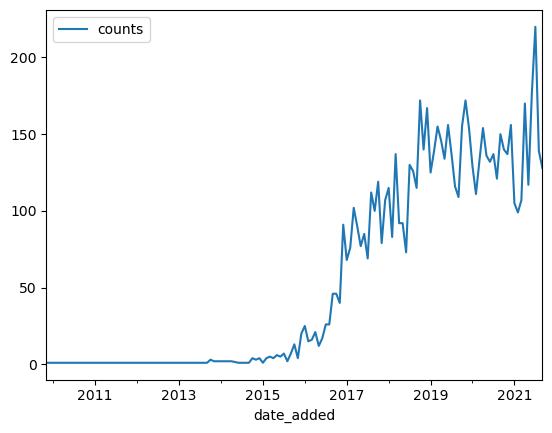

In [78]:
result_2.plot(kind="line", x='date_added', y='counts')

Netflix added very few titles before 2015, but growth accelerated sharply afterward.

Between 2017 and 2021, additions peaked with frequent fluctuations, often crossing 200 titles.

This shows Netflix’s rapid expansion phase starting mid‑2010s, reflecting aggressive content growth.



#  Explore the length of movies or episodes and identify any trends

In [79]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [80]:
data.duration.nunique()

196

In [81]:
ans = data['duration'].value_counts().sort_values(ascending=False).reset_index()
ans

,duration,count
0,1 Season,1708
1,2 Seasons,406
2,3 Seasons,196
3,90 min,137
4,91 min,128
...,...,...
191,179 min,1
192,31 min,1
193,43 min,1
194,173 min,1


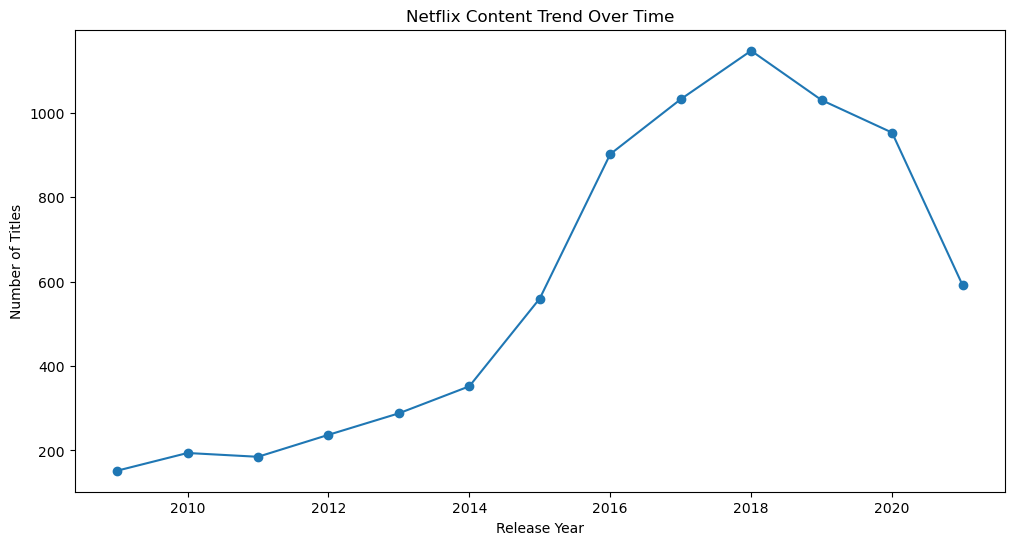

In [82]:
# Group by year
yearly_counts = data.groupby("release_year").size()

# Plot
plt.figure(figsize=(12,6))
yearly_counts.plot(kind="line", marker="o")
plt.title("Netflix Content Trend Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()


Netflix steadily grew its catalog until 2015, then surged sharply, peaking around 2018 with over 1,000 titles.

After 2018, the number of new releases declined, dropping to about half by 2021.

This shows Netflix’s rapid expansion phase followed by a slowdown, likely due to strategic shifts or market saturation.



# Genre Trends:
***Analyze trends in the popularity of different genres over time.***

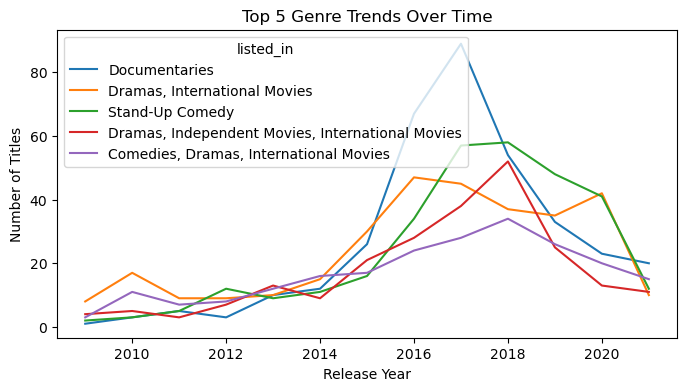

In [83]:
genre_trends = data.groupby(['release_year','listed_in']).size().unstack(fill_value = 0)
top_genre = genre_trends.sum().nlargest(5).index
genre_trends[top_genre].plot(kind= 'line',figsize=(8,4))
plt.title('Top 5 Genre Trends Over Time')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

Documentaries and Stand‑Up Comedy saw sharp growth around 2017, showing rising audience interest.

Drama‑based categories grew steadily but without sudden spikes, reflecting consistent demand.

Overall, Netflix expanded diverse genres over time, with comedy and documentaries becoming standout trends.

 # Correlation Analysis:
***Investigate potential correlations between variables (e.g., ratings and duration).***


In [87]:
data['duration_num'] = data['duration'].str.extract('(\d+)').astype(float)
avg_duration_by_rating = data.groupby('rating')['duration_num'].mean().dropna()
print(avg_duration_by_rating)

rating
66 min        1.000000
74 min        1.000000
84 min        1.000000
G            82.333333
NC-17       125.000000
NR           89.647059
PG           95.430939
PG-13       106.652318
R           104.107639
TV-14        67.736814
TV-G         47.201970
TV-MA        61.118283
TV-PG        55.125000
TV-Y         21.655518
TV-Y7        30.419672
TV-Y7-FV     57.333333
UR          103.000000
Name: duration_num, dtype: float64


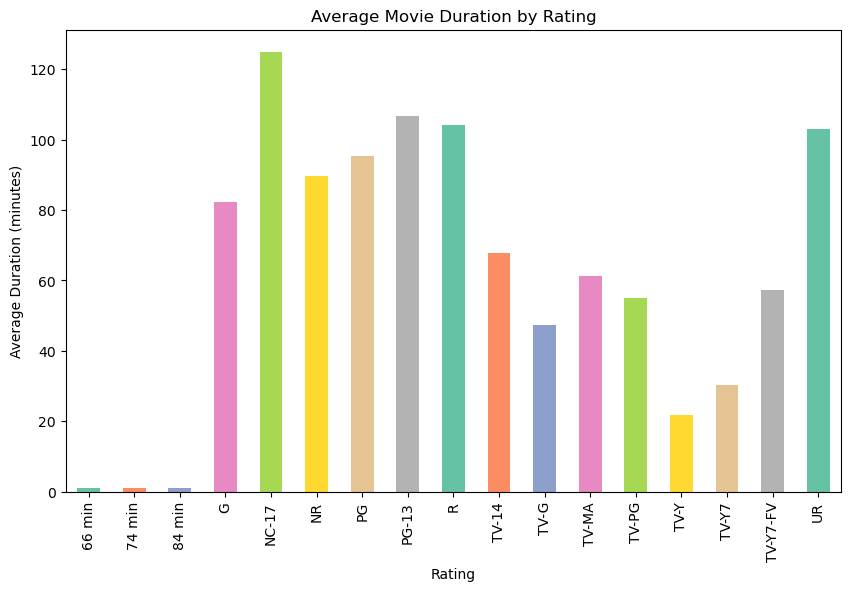

In [88]:
plt.figure(figsize=(10,6))
colors = sns.color_palette("Set2", len(avg_duration_by_rating))
avg_duration_by_rating.plot(kind='bar', color=colors)
plt.title("Average Movie Duration by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Duration (minutes)")
plt.show()


Movies with adult ratings like NC‑17 tend to be longest, averaging around 125 minutes.

Kids’ ratings such as TV‑Y have the shortest durations, often near 20 minutes, showing clear differences by audience type.

# Content Analysis 
***Analyze the distribution of content ratings***

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9940\4042881451.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data['rating'], order=data['rating'].value_counts().index, palette="viridis")


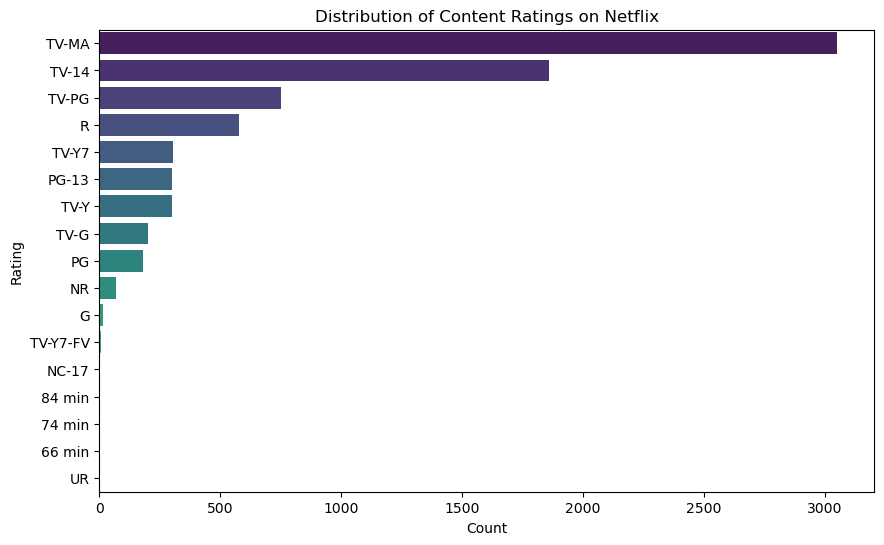

In [92]:

import seaborn as sns




# Countplot for ratings
plt.figure(figsize=(10,6))
sns.countplot(y=data['rating'], order=data['rating'].value_counts().index, palette="viridis")
plt.title("Distribution of Content Ratings on Netflix")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()


Netflix’s catalog is dominated by mature content (TV‑MA), followed by TV‑14 and TV‑PG, showing a strong tilt toward adult and teen audiences.

Ratings like NC‑17, UR, and G appear very rarely, highlighting limited family‑friendly or niche content compared to mainstream mature titles.



# Content Analysis
***Explore the length of movies or episodes and identify any trends***

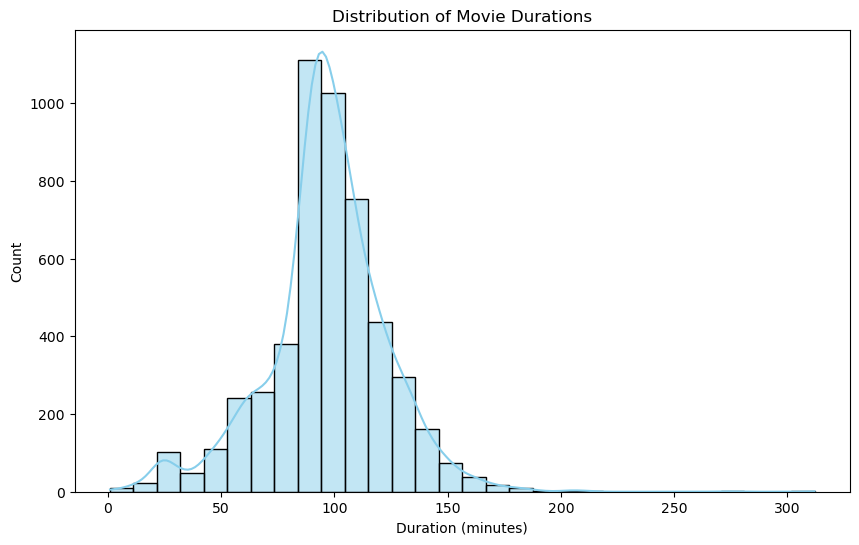

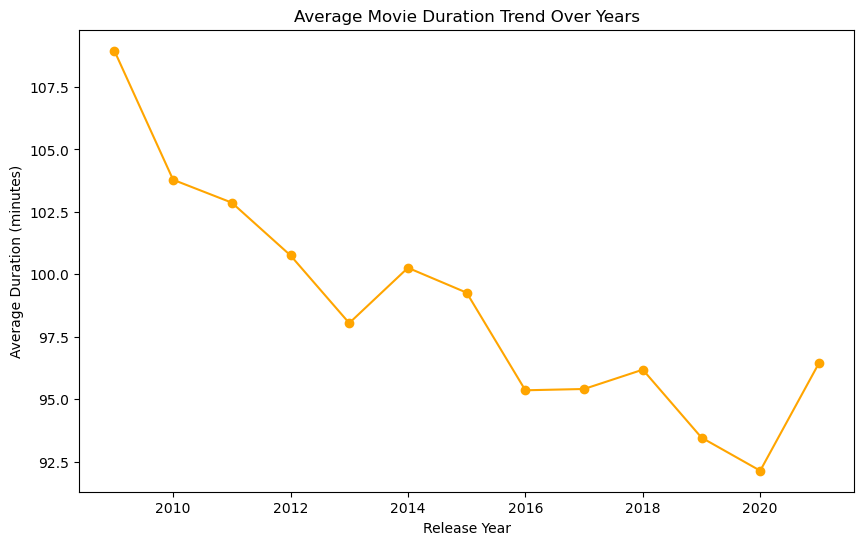

In [93]:


# --- Step 2: Filter only movies ---
movies = data[data['type'] == 'Movie']

# --- Step 3: Distribution of movie durations ---
plt.figure(figsize=(10,6))
sns.histplot(movies['duration_num'].dropna(), bins=30, kde=True, color="skyblue")
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()

# --- Step 4: Trend of average duration over release years ---
avg_duration = movies.groupby('release_year')['duration_num'].mean()

plt.figure(figsize=(10,6))
avg_duration.plot(kind='line', marker='o', color="orange")
plt.title("Average Movie Duration Trend Over Years")
plt.xlabel("Release Year")
plt.ylabel("Average Duration (minutes)")
plt.show()


Most Netflix movies cluster around 90–100 minutes, showing the standard length for mainstream films.

The average duration has gradually declined from ~109 minutes in 2009 to ~92 minutes in 2020, suggesting shorter films are becoming more common.

This trend reflects changing audience preferences toward quicker, more concise storytelling in recent years.

# Top Lists and Recommendations:
***Identify and present top-rated movies or TV shows based on user ratings***

In [94]:


# --- Step 1: Check available ratings ---
print(data['rating'].unique())

# --- Step 2: If you have numeric user ratings column (e.g., 'user_rating') ---
# Sort by rating and pick top 10
top_rated = data.sort_values(by='rating', ascending=False).head(10)
print("Top 10 Rated Titles:")
print(top_rated[['title','type','rating','release_year']])

# --- Step 3: Separate Movies and TV Shows ---
top_movies = data[data['type']=='Movie'].sort_values(by='rating', ascending=False).head(10)
top_shows  = data[data['type']=='TV Show'].sort_values(by='rating', ascending=False).head(10)

print("\nTop 10 Movies:")
print(top_movies[['title','rating','release_year']])

print("\nTop 10 TV Shows:")
print(top_shows[['title','rating','release_year']])


['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' 'TV-Y7-FV' 'UR']
Top 10 Rated Titles:
                                                  title     type    rating  \
7988                                           Sex Doll    Movie        UR   
7317                Little Singham aur Kaal ka Mahajaal    Movie  TV-Y7-FV   
7290  LEGO Ninjago: Masters of Spinjitzu: Day of the...    Movie  TV-Y7-FV   
6581                                       Dear Dracula    Movie  TV-Y7-FV   
7646                      Oh No! It's an Alien Invasion  TV Show  TV-Y7-FV   
7513                          Motu Patlu: King of Kings    Movie  TV-Y7-FV   
7292                                       Leo the Lion    Movie  TV-Y7-FV   
8600                                              Tobot  TV Show     TV-Y7   
1758                                       LEGO Ninjago  TV Show     TV-Y7   
5659  A Christmas Special: Miraculous: Tales of Lady...    Movie     TV-Y

# Content Evolution Over Time:
***Explore how the characteristics of content (e.g., duration, ratings) have evolved over the
years***

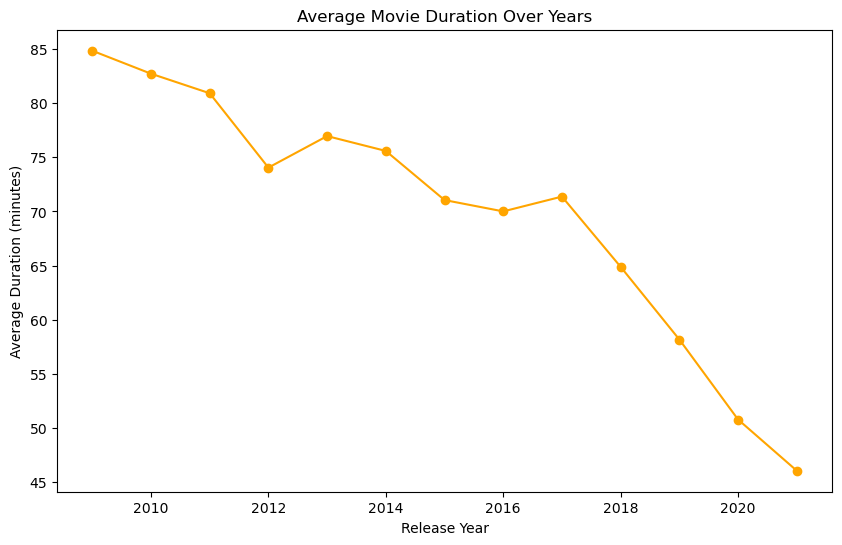

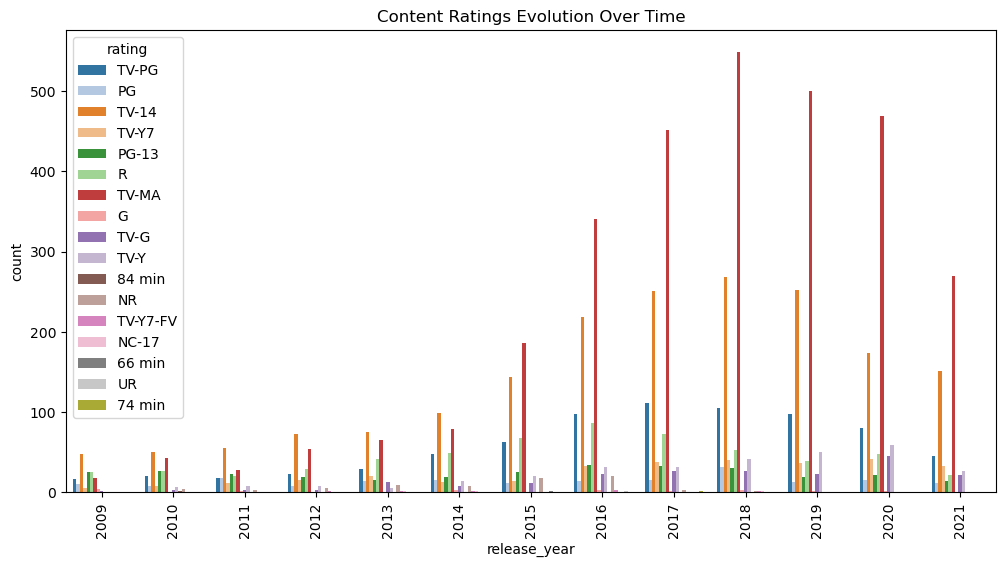

In [96]:


avg_duration = data.groupby('release_year')['duration_num'].mean()
avg_duration.plot(kind='line', marker='o', color="orange", figsize=(10,6))
plt.title("Average Movie Duration Over Years")
plt.xlabel("Release Year")
plt.ylabel("Average Duration (minutes)")
plt.show()

# Rating distribution over years
plt.figure(figsize=(12,6))
sns.countplot(x='release_year', hue='rating', data=data, palette="tab20")
plt.title("Content Ratings Evolution Over Time")
plt.xticks(rotation=90)
plt.show()


Ratings Evolution: Netflix shifted strongly toward TV‑MA and TV‑14 content after 2015, peaking around 2017–2019. This shows a clear focus on mature and teen audiences in recent years.

Duration Trend: Average movie length steadily declined from ~85 minutes in 2009 to ~46 minutes by 2021, reflecting shorter storytelling formats and changing viewer habits.

# Conclusions and Recommendations:
***Summarize the key findings, draw conclusions, and provide recommendations based on
the insights gained from the analysis***

***Conclusions:
Netflix has more movies than TV shows.
Drama, international content, and documentaries are the most popular genres.
Content growth increased rapidly after 2015.
USA and India produce the most content.***


***Recommendations:
Add more diverse international content.
Increase the number of TV shows for better engagement.
Explore new and niche genres.
Include more classic/older content for variety.***